In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#Credit Card Dataset
data = pd.read_csv(r"C:\Users\Given\Downloads\credit card dataset.csv", sep=";")

# Exploritory Data Analysis

In [3]:
print("\nDataset Info:")
data.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


<span style="font-size:22px;">The Dataset has 31 variables, of which 30 are predictors with n = 284 807</span>

In [4]:
display(data.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,...,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,...,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,...,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,...,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,...,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


## 1. Checking for amongst the covariates with a threshold of > 75%

In [5]:
corr_matrix = data.corr().abs()
high_corr_vars = [(i, j, corr_matrix.loc[i, j]) 
                  for i in corr_matrix.columns 
                  for j in corr_matrix.columns 
                  if i != j and corr_matrix.loc[i, j] > 0.75]
print("\nHighly Correlated Variables (Threshold > 0.75):")
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    print(f"{var1} - {var2}: {corr:.2f}")


Highly Correlated Variables (Threshold > 0.75):


<span style="font-size:20px;">There are no covariates with high multicolinearity within the dataset</span>

## 2. Checking the Dataset for missing values

In [6]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


<span style="font-size:20px;">There are no missing values within the dataset</span>

## 3. Cheking the imbalance of the response variable 'Class'

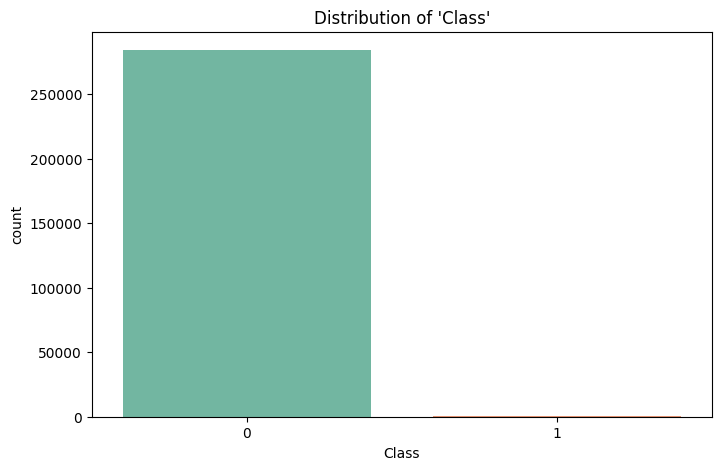

In [7]:
# Distribution of the response variable
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Class', hue='Class', palette='Set2', legend=False)
plt.title("Distribution of 'Class'")
plt.show()

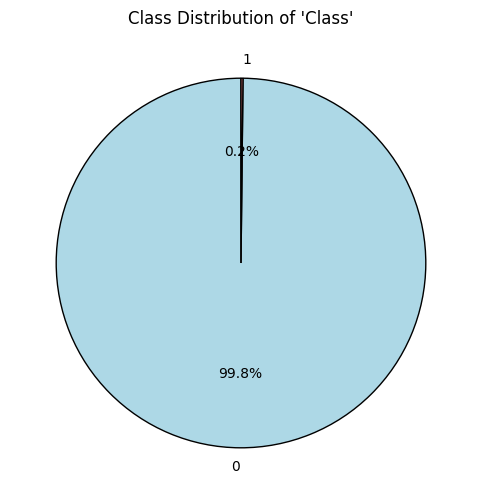


Class Counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(6, 6))
data['Class'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution of 'Class'")
plt.ylabel("")
plt.show()

print("\nClass Counts:")
print(data['Class'].value_counts())

## 4. Checking for outliers using Boxplots

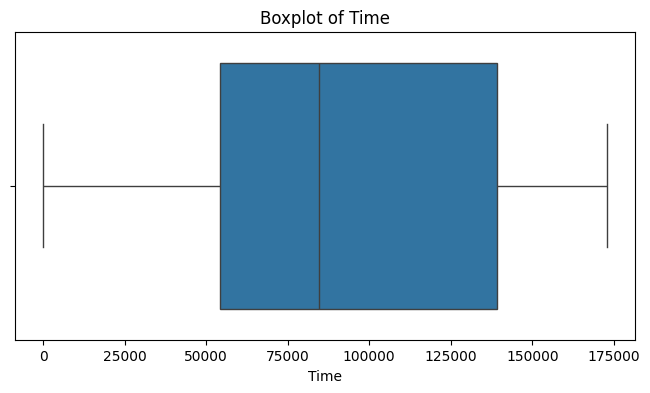

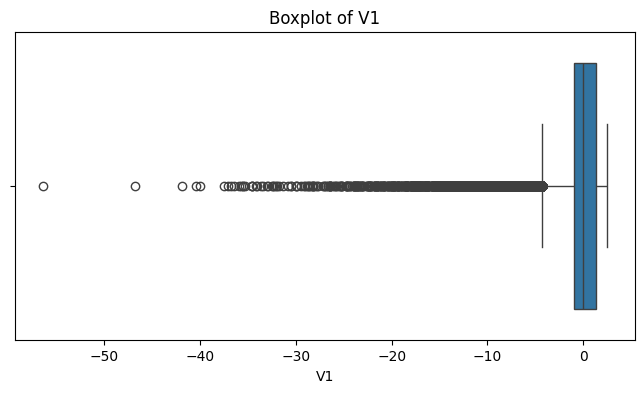

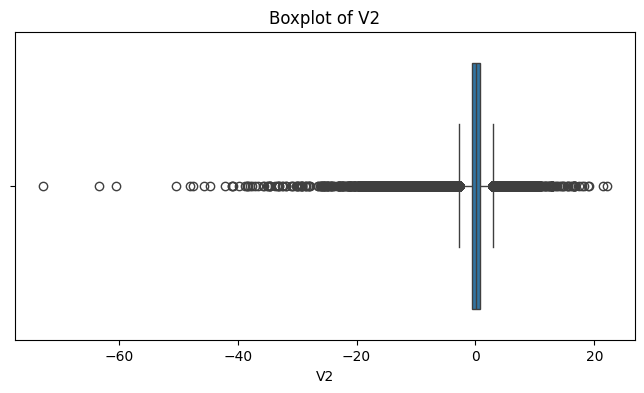

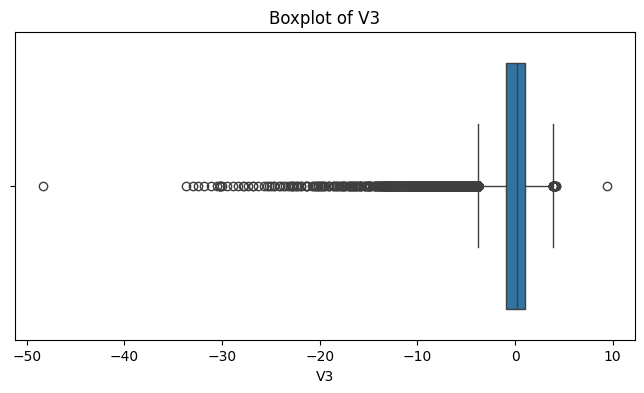

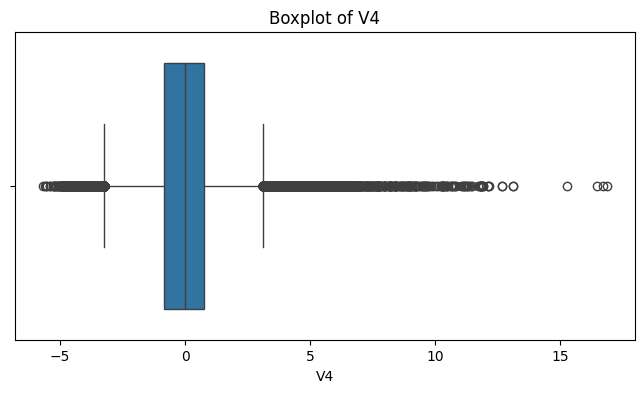

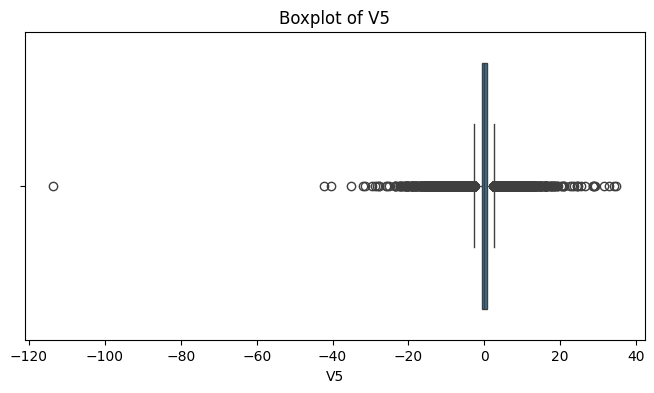

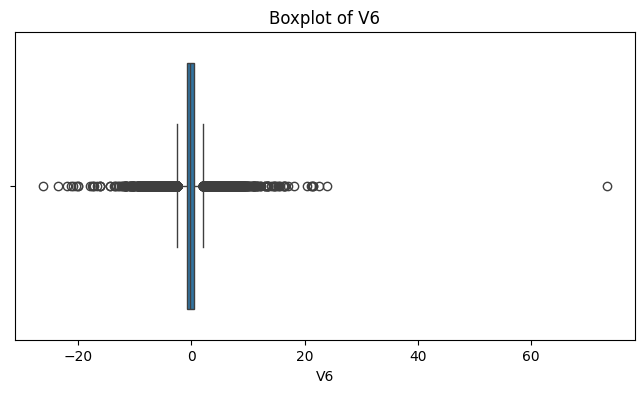

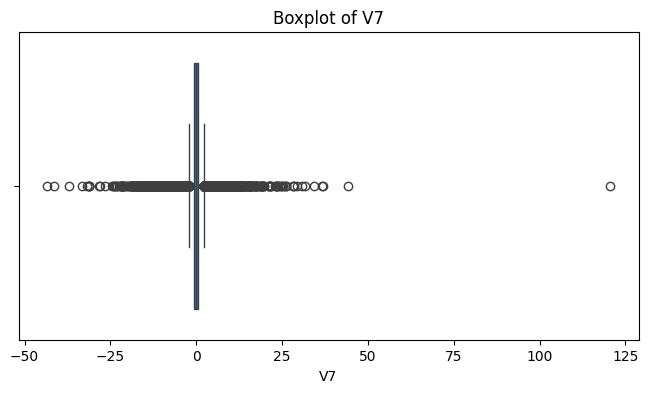

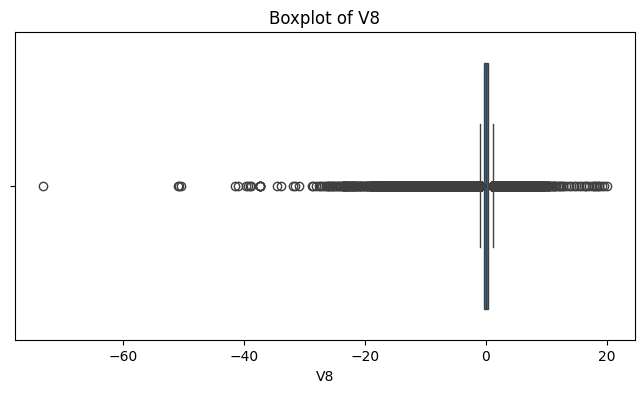

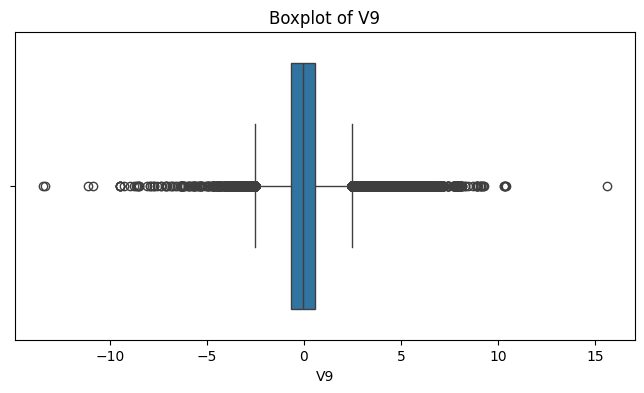

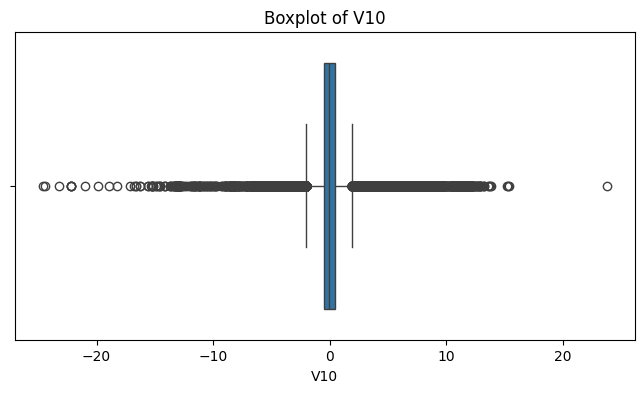

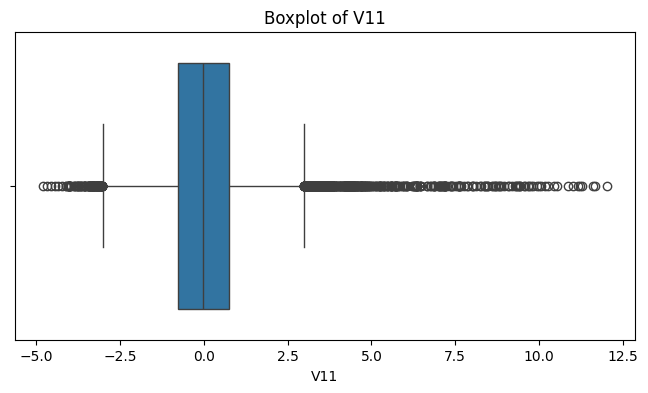

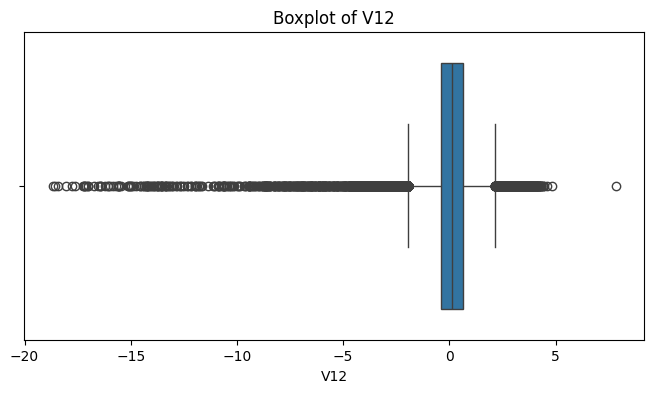

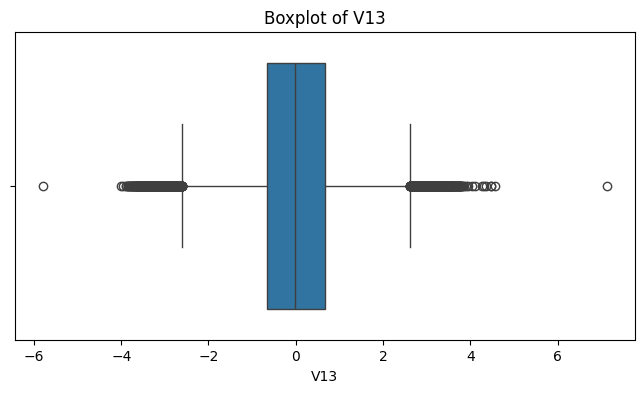

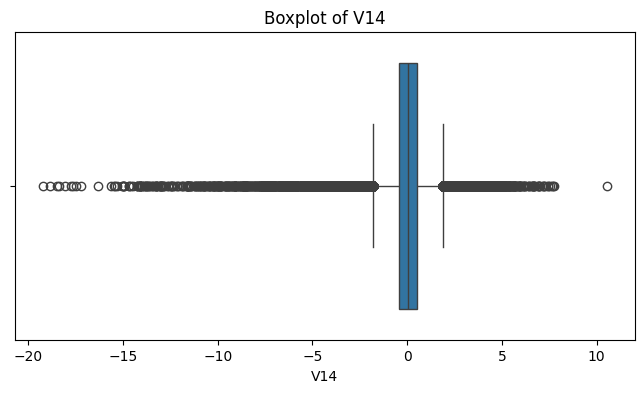

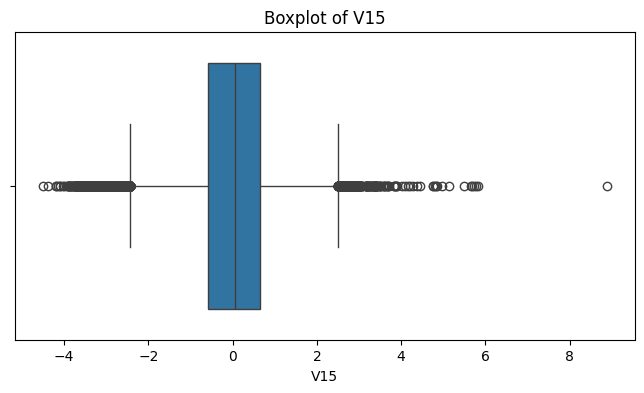

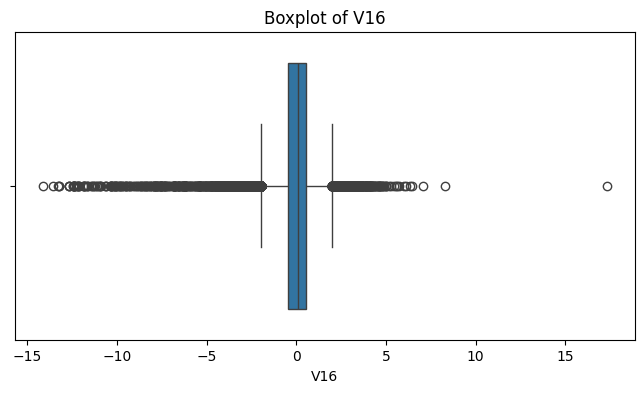

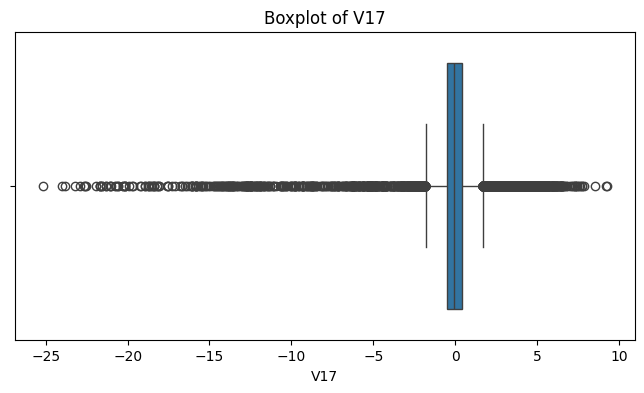

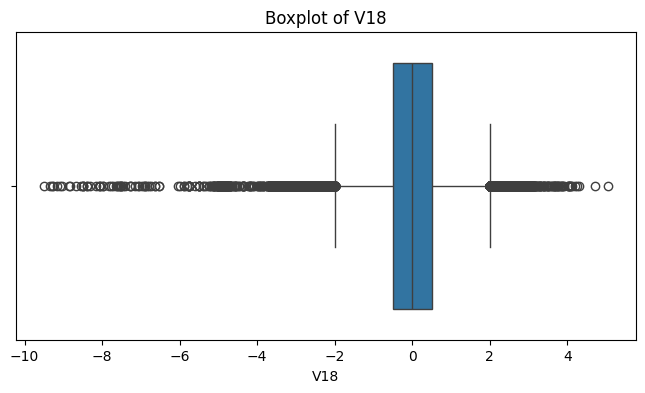

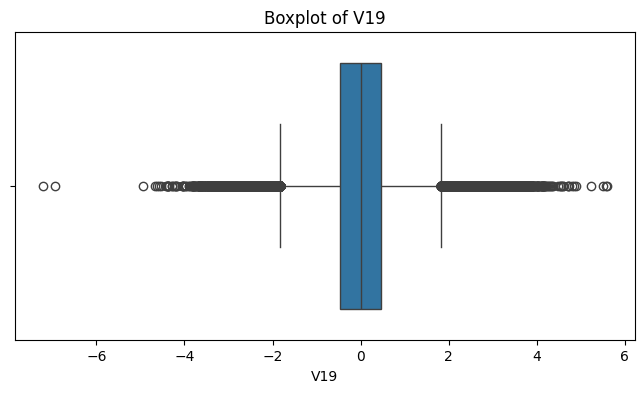

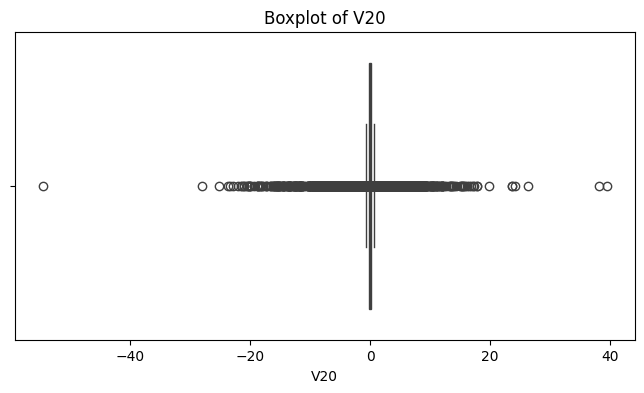

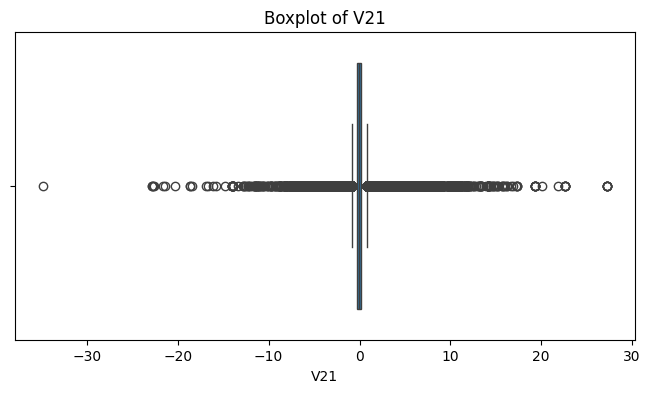

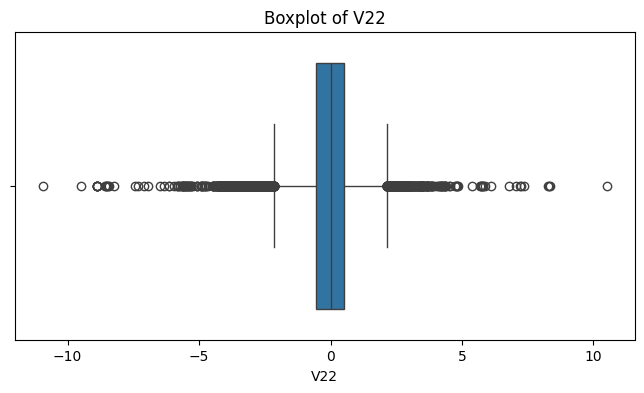

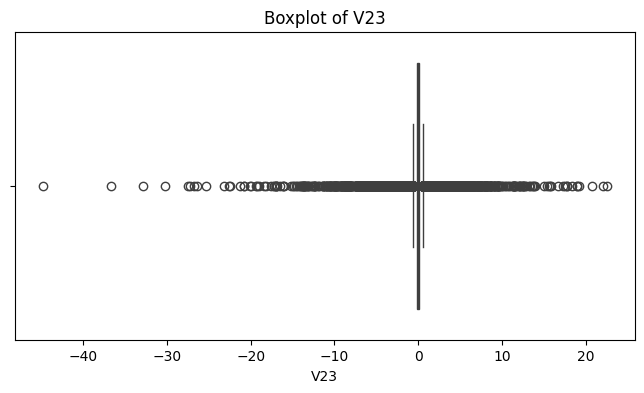

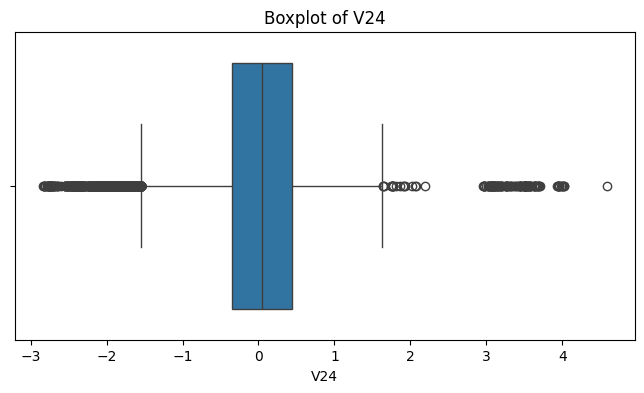

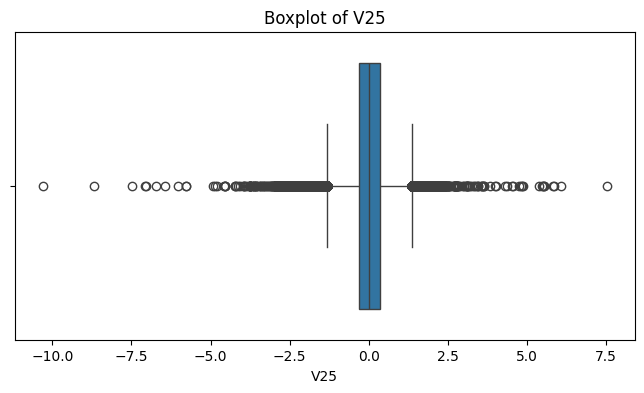

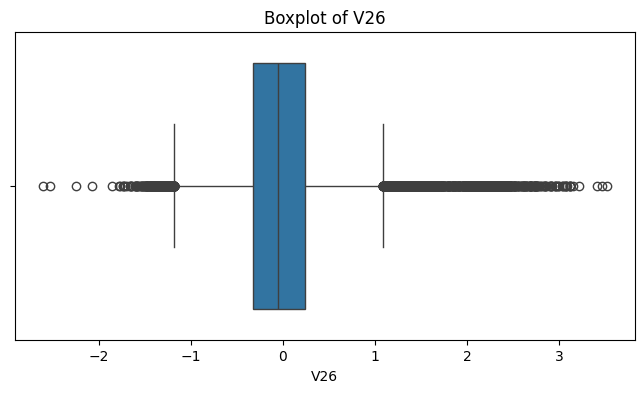

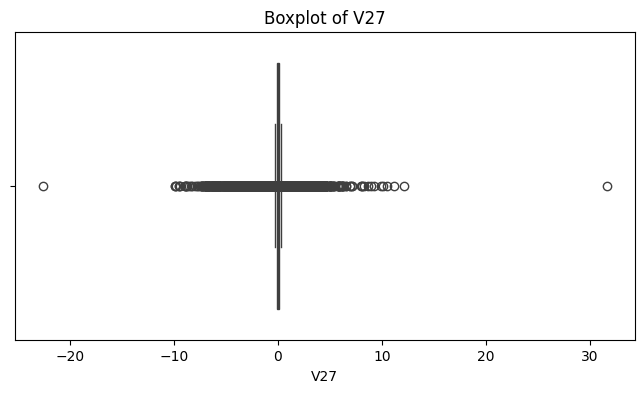

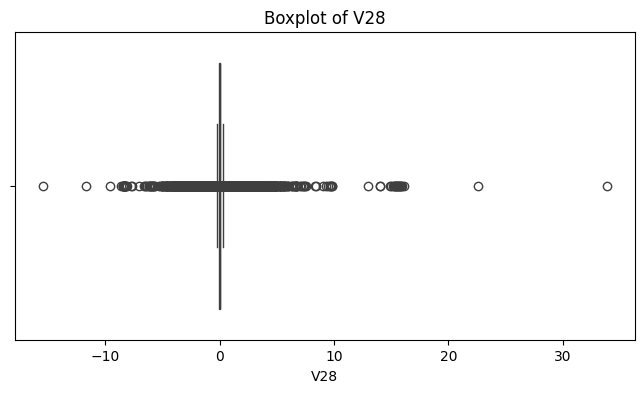

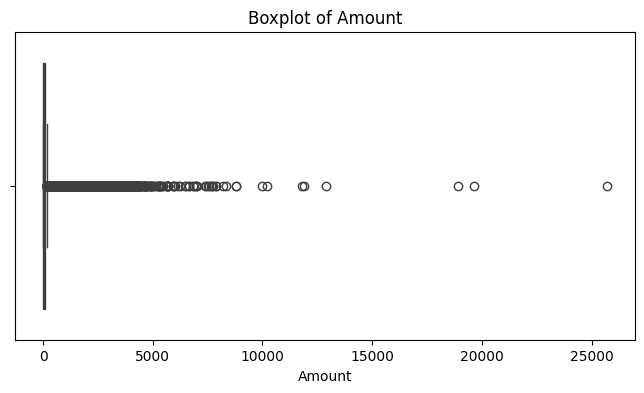

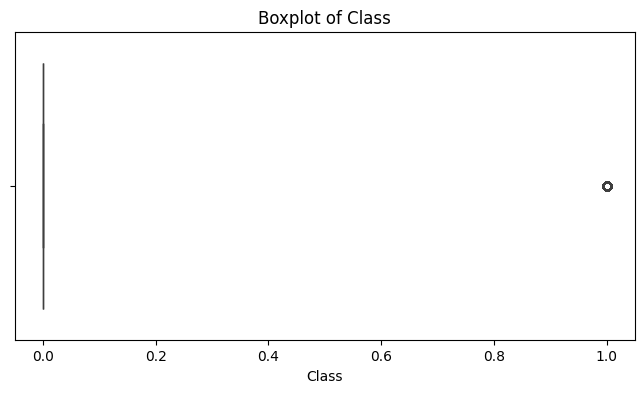

In [9]:
num_cols = data.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Model Picking - Lazy Predict

## 1. Process of picking the models

Lazy Predict will be executed on the Health Insurance and Credit Card Fraud datasets to consolidate the base models from both datasets. I will individually select the top 15 performing Lazy Predict models for each dataset out of the 32 offered. Consequently, I will analyze the 15 models from each set to determine the models that are commonly found in both sets. The objective is to construct ensemble stacking models using base models that both datasets share, to achieve uniformity in the base models used for modeling.

## 2. Lazy Predict

In [10]:
X, y = data.drop(columns=['Class']), data['Class']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = StandardScaler().fit_transform(X_train), StandardScaler().fit_transform(X_test)

In [12]:
models, _ = LazyClassifier(verbose=0, ignore_warnings=True).fit(X_train, X_test, y_train, y_test)
print(models)

  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 97%|███████████████████████████████████████████████████████████████████████████████▍  | 31/32 [26:22<01:07, 67.49s/it]

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [26:25<00:00, 49.56s/it]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
QuadraticDiscriminantAnalysis      0.98               0.94     0.94      0.99   
BaggingClassifier                  1.00               0.90     0.90      1.00   
DecisionTreeClassifier             1.00               0.90     0.90      1.00   
GaussianNB                         0.98               0.90     0.90      0.99   
ExtraTreesClassifier               1.00               0.89     0.89      1.00   
XGBClassifier                      1.00               0.89     0.89      1.00   
KNeighborsClassifier               1.00               0.89     0.89      1.00   
RandomForestClassifier             1.00               0.88     0.88      1.00   
NearestCentroid                    1.00               0.88     0.88      1.00   
LinearDiscriminantAnalysis         1.00               0.87     0.87      1.00   
ExtraTreeClassifier         

## 3. Top 15 Models from the Credit Card Dataset

1. **QuadraticDiscriminantAnalysis**  
2. **BaggingClassifier**  
3. **DecisionTreeClassifier**  
4. **GaussianNB**  
5. **ExtraTreesClassifier**  
6. **XGBClassifier**  
7. **KNeighborsClassifier**  
8. **RandomForestClassifier**  
9. **NearestCentroid**  
10. **LinearDiscriminantAnalysis**  
11. **ExtraTreeClassifier**  
12. **Perceptron**  
13. **AdaBoostClassifier**  
14. **BernoulliNB**  
15. **SVC**  

## 4. List of similar models from both datasets within the Top 15

  1. **LinearDiscriminantAnalysis**  
  2. **XGBClassifier**  
  3. **NearestCentroid**  
  4. **SGDClassifier**  
  5. **ExtraTreeClassifier**  
  6. **SVC**  

# Modelling

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC

## 1. Linear Discriminant Analysis

In [14]:
# Initialize
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [15]:
# Make predictions
y_pred_LDA = lda.predict(X_test)

In [16]:
# Evaluating the model
accuracy_LDA = accuracy_score(y_test, y_pred_LDA)
conf_matrix_LDA = confusion_matrix(y_test, y_pred_LDA)
class_report_LDA = classification_report(y_test, y_pred_LDA)

print(f'Accuracy: {accuracy_LDA:.4f}')
print('Classification Report:')
print(class_report_LDA)

Accuracy: 0.9994
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.74      0.80        98

    accuracy                           1.00     56962
   macro avg       0.93      0.87      0.90     56962
weighted avg       1.00      1.00      1.00     56962



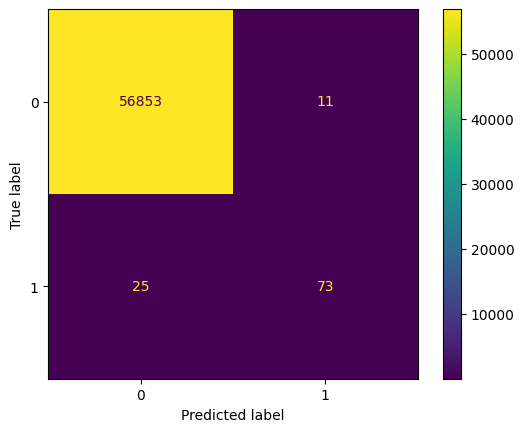

In [17]:
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LDA, display_labels=lda.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8071922336576216


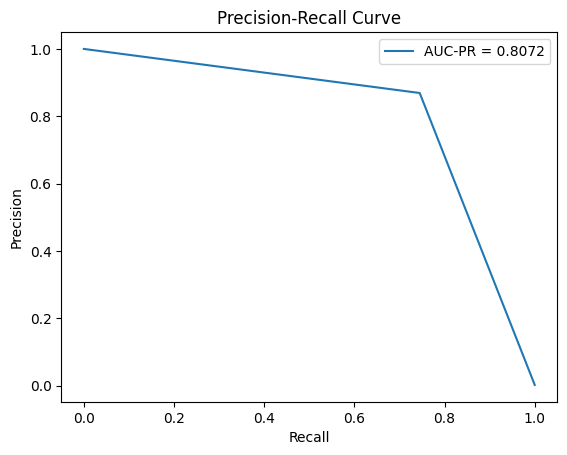

In [18]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_LDA)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 2. XGBClassifier

In [19]:
# Initialize
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [20]:
# Make Predictions
y_pred_XGB = xgb.predict(X_test)

In [21]:
# Evaluating the model
accuracy_XGB = accuracy_score(y_test, y_pred_XGB)
conf_matrix_XGB = confusion_matrix(y_test, y_pred_XGB)
class_report_XGB = classification_report(y_test, y_pred_XGB)

print(f'Accuracy: {accuracy_XGB:.4f}')
print('Classification Report:')
print(class_report_XGB)

Accuracy: 0.9996
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



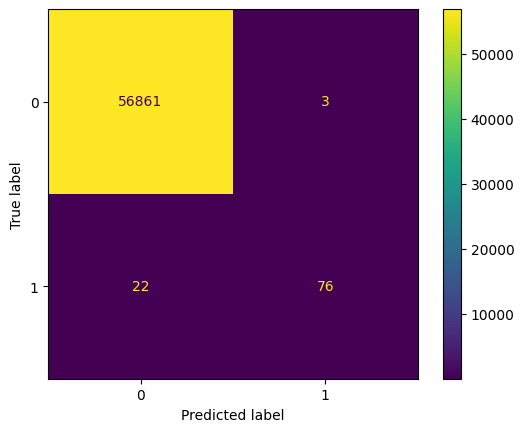

In [22]:
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_XGB, display_labels=xgb.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8689608714656027


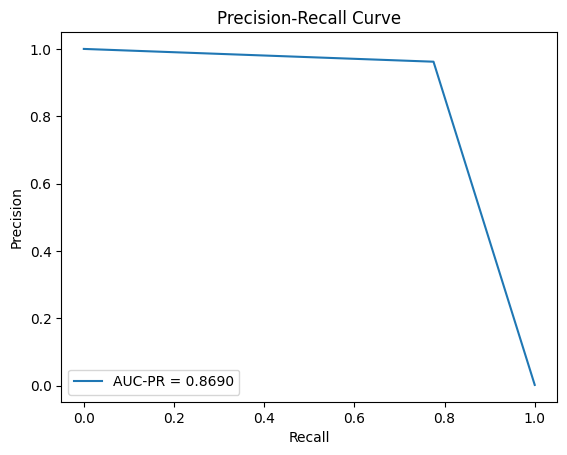

In [23]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_XGB)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 3. Nearest Centroid

In [24]:
# Initialze
nc = NearestCentroid()
nc.fit(X_train, y_train)

NearestCentroid()

In [25]:
# Make Predictions
y_pred_NC = nc.predict(X_test)

In [26]:
# Evaluating the model
accuracy_NC = accuracy_score(y_test, y_pred_NC)
conf_matrix_NC = confusion_matrix(y_test, y_pred_NC)
class_report_NC = classification_report(y_test, y_pred_NC)

print(f'Accuracy: {accuracy_NC:.4f}')
print('Classification Report:')
print(class_report_NC)

Accuracy: 0.9994
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.77      0.82        98

    accuracy                           1.00     56962
   macro avg       0.94      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



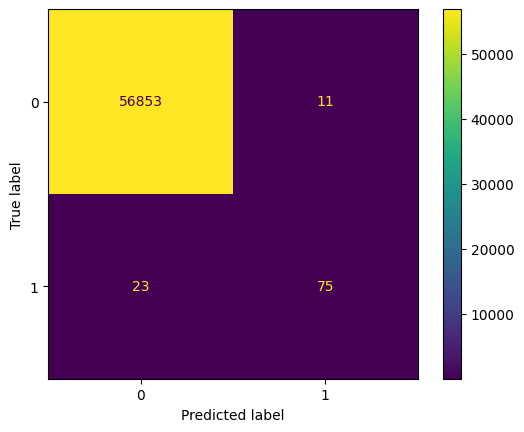

In [27]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_NC, display_labels=nc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8189014618310141


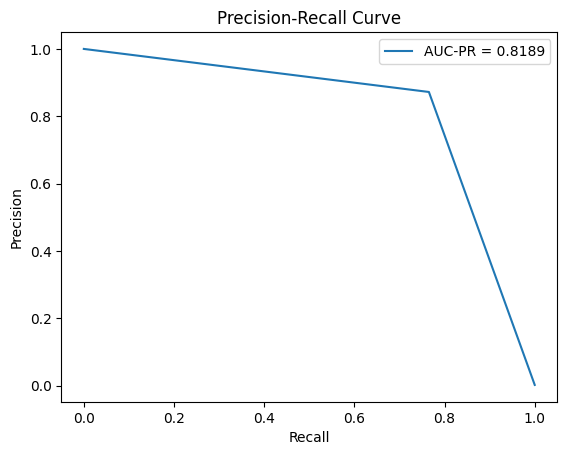

In [28]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_NC)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 4. SGD Classifier

In [29]:
# Initialize
sgd = SGDClassifier(loss="log_loss", random_state=42)  # 'log_loss' for probability estimates
sgd.fit(X_train, y_train)

SGDClassifier(loss='log_loss', random_state=42)

In [30]:
# Make predictions
y_pred_SGD = sgd.predict(X_test)

In [31]:
# Evaluating the model
accuracy_SGD = accuracy_score(y_test, y_pred_SGD)
conf_matrix_SGD = confusion_matrix(y_test, y_pred_SGD)
class_report_SGD = classification_report(y_test, y_pred_SGD)

print(f'Accuracy: {accuracy_SGD:.4f}')
print('Classification Report:')
print(class_report_SGD)

Accuracy: 0.9989
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.46      0.59        98

    accuracy                           1.00     56962
   macro avg       0.92      0.73      0.80     56962
weighted avg       1.00      1.00      1.00     56962



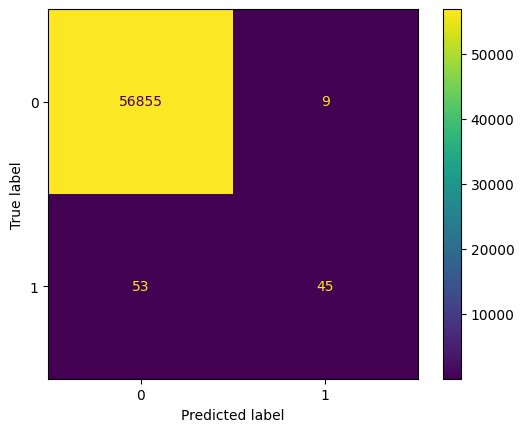

In [32]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SGD, display_labels=sgd.classes_)
disp.plot()
plt.show()

AUC-PR: 0.6467237258303484


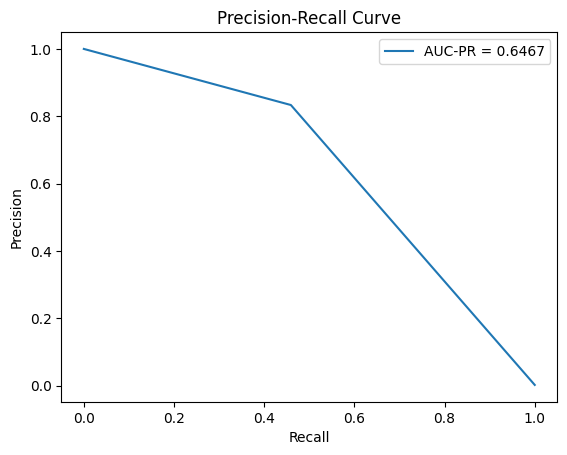

In [33]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_SGD)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 5. Extra Tree Classifier

In [34]:
# Initialize
extra_tree = ExtraTreesClassifier(random_state=42)
extra_tree.fit(X_train, y_train)

ExtraTreesClassifier(random_state=42)

In [35]:
# Make predictions
y_pred_ET = extra_tree.predict(X_test)

In [36]:
# Evaluating the model
accuracy_ET = accuracy_score(y_test, y_pred_ET)
conf_matrix_ET = confusion_matrix(y_test, y_pred_ET)
class_report_ET = classification_report(y_test, y_pred_ET)

print(f'Accuracy: {accuracy_ET:.4f}')
print('Classification Report:')
print(class_report_ET)

Accuracy: 0.9996
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



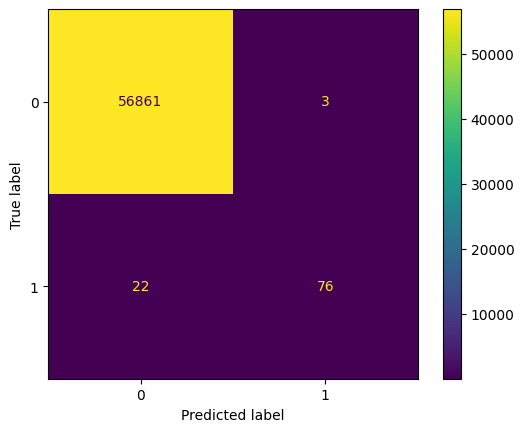

In [37]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ET, display_labels=extra_tree.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8689608714656027


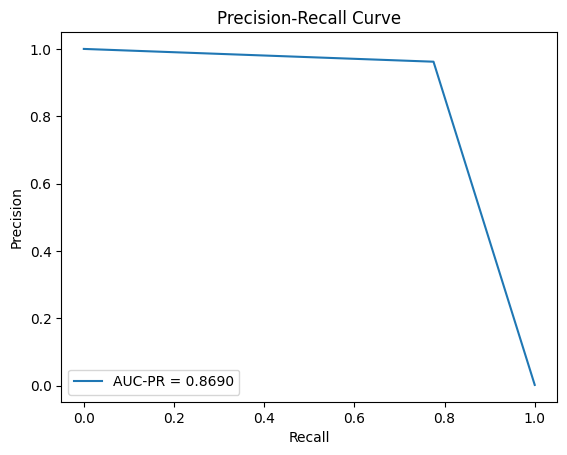

In [38]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_ET)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 6. Support Vector Classifier

In [39]:
# Initialize
svc = SVC(kernel='rbf', probability=True, random_state=42) 
svc.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [40]:
# Make predictions
y_pred_SVC = svc.predict(X_test)

In [41]:
# Evaluating the model
accuracy_SVC = accuracy_score(y_test, y_pred_SVC)
conf_matrix_SVC = confusion_matrix(y_test, y_pred_SVC)
class_report_SVC = classification_report(y_test, y_pred_SVC)

print(f'Accuracy: {accuracy_SVC:.4f}')
print('Classification Report:')
print(class_report_SVC)

Accuracy: 0.9993
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.61      0.75        98

    accuracy                           1.00     56962
   macro avg       0.98      0.81      0.87     56962
weighted avg       1.00      1.00      1.00     56962



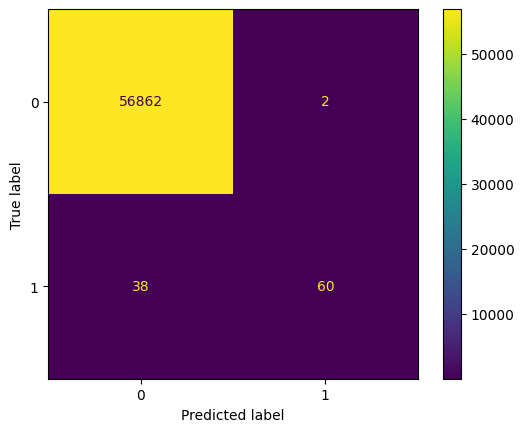

In [42]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SVC, display_labels=svc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8518156381607307


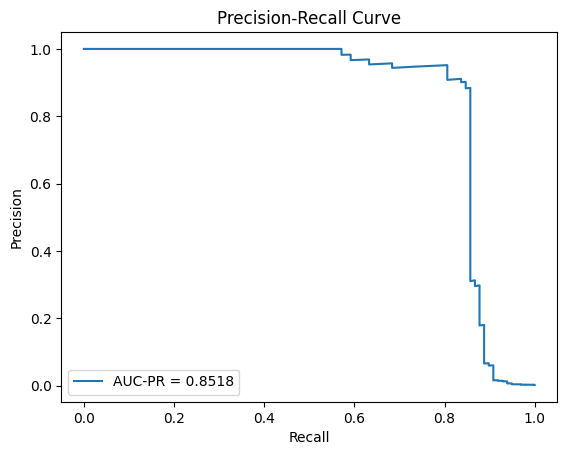

In [43]:
# AUC-PR
y_scores_SVC = svc.decision_function(X_test)
precision, recall, _ = precision_recall_curve(y_test, y_scores_SVC)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Stacking Ensemble Model

In [44]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

In [45]:
# Base models
base_models = [
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', tree_method='hist', n_jobs=-1)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42, n_jobs=-1)),
    ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ('svc', SVC(probability=True, random_state=42))
]

In [46]:
# Meta-learner
meta_learner = LogisticRegression(n_jobs=-1)

In [47]:
# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [48]:
# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=cv_strategy, n_jobs=-1)

In [49]:
# Train model
stacking_model.fit(X_train, y_train)

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('lda', LinearDiscriminantAnalysis()),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feat...
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=-1,
                                              num_parallel_tree=None,
                                              random_state=None, ...)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss', n_jobs=-1,
                                              random_state=42)),
                               ('etc',
                                ExtraTreesClassifier(n_estimators=50, n_jobs=-1,
                                                     random_state=42)),
                               ('svc', SVC(probability=True, random_state=42))],
                   final_estimator=LogisticRegression(n_jobs=-1), n_jobs=-1)

In [50]:
# Make predictions
y_pred_stack = stacking_model.predict(X_test)

In [51]:
# Evaluate model
accuracy_stack = accuracy_score(y_test, y_pred_stack)
class_report_stack = classification_report(y_test, y_pred_stack)

print(f'Stacking Ensemble Accuracy: {accuracy_stack:.4f}')
print('Classification Report:')
print(class_report_stack)

Stacking Ensemble Accuracy: 0.9995
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.73      0.84        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



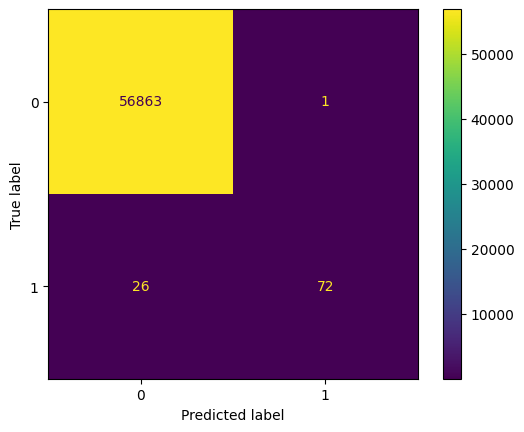

In [52]:
# Confusion Matrix
conf_matrix_stack = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack, display_labels=stacking_model.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8607


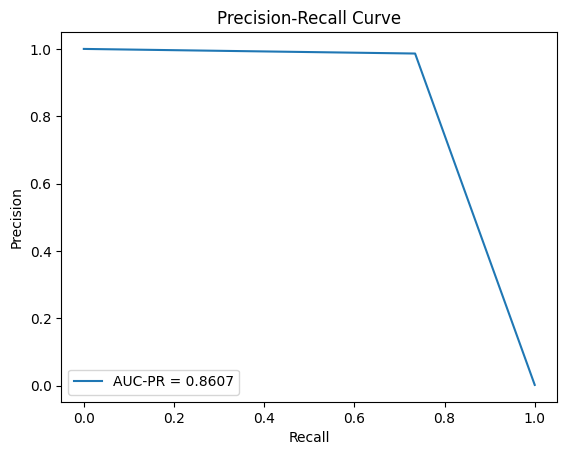

In [53]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_stack)
auc_pr = auc(recall, precision)
print(f"AUC-PR: {auc_pr:.4f}")

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Voting Ensemble Model

In [54]:
from sklearn.ensemble import VotingClassifier

In [55]:
voting_model = VotingClassifier(estimators=base_models, voting='soft')

In [56]:
# Train Model
voting_model.fit(X_train, y_train)

VotingClassifier(estimators=[('lda', LinearDiscriminantAnalysis()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=Non...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=-1,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('nc', NearestCentroid()),
                             ('sgd',
                              SGDClassifier(loss='log_loss', n_jobs=-1,
                                            random_state=42)),
                             ('etc',
                              ExtraTreesClassifier(n_estimators=50, n_jobs=-1,
                                                   random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [57]:
# Make predictions
y_pred_vote = voting_model.predict(X_test)

In [58]:
# Evaluate model
accuracy_vote = accuracy_score(y_test, y_pred_vote)
class_report_vote = classification_report(y_test, y_pred_vote)

print(f'Voting Ensemble Accuracy: {accuracy_vote:.4f}')
print('Classification Report:')
print(class_report_vote)

Voting Ensemble Accuracy: 0.9994
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.74      0.81        98

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



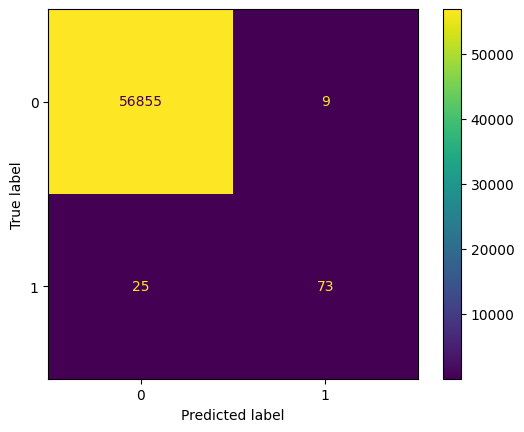

In [59]:
# Confusion matrix
conf_matrix_vote = confusion_matrix(y_test, y_pred_vote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_vote, display_labels=voting_model.classes_)
disp.plot()
plt.show()

AUC-PR: 0.8178


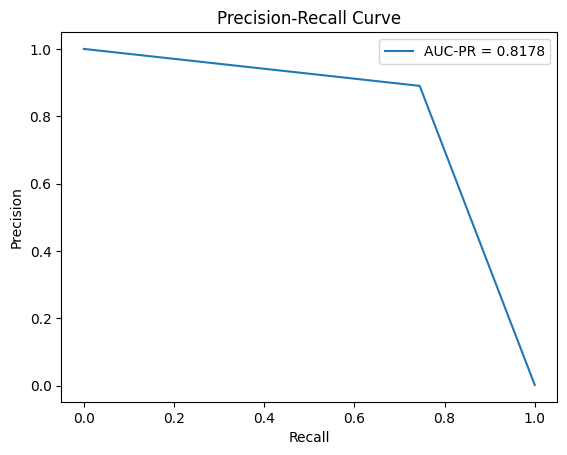

In [60]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_vote)
auc_pr = auc(recall, precision)
print(f"AUC-PR: {auc_pr:.4f}")

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# SHAP for Explainability - Stacking Ensemble

In [61]:
import shap

In [62]:
# Extract meta-learner
meta_learner = stacking_model.final_estimator_

In [91]:
# Get transformed features (outputs from base models)
X_test_meta = stacking_model.transform(X_test)

In [92]:
# Create feature names for the transformed data
base_model_names = [name for name, _ in base_models]
feature_names = []

for model_name in base_model_names:
    # Add appropriate feature names based on your model outputs
    feature_names.append(f"{model_name}_prediction")

In [95]:
# Convert to DataFrame with proper feature names
X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names)

In [96]:
# SHAP Explainer for meta-learner
explainer = shap.Explainer(meta_learner, X_test_meta_df)
shap_values = explainer(X_test_meta_df)

In [97]:
# Subsample for plotting
sample_indices = np.random.choice(len(X_test_meta_df), size=2000, replace=False)
shap_values_sampled = shap_values[sample_indices]
X_test_meta_sampled = X_test_meta_df.iloc[sample_indices]


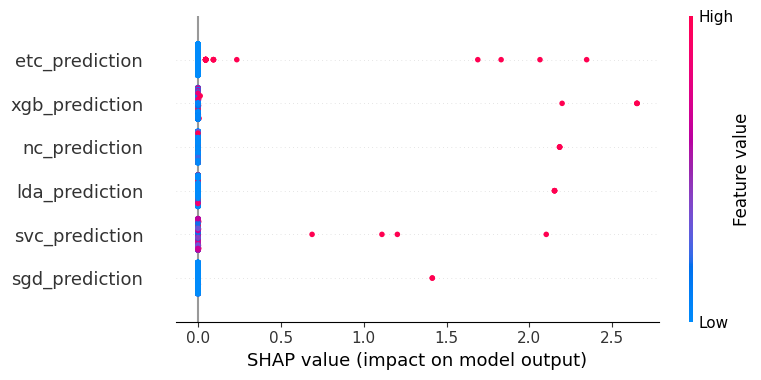

In [98]:
# Summary Plot (Feature Importance)
shap.summary_plot(shap_values_sampled, X_test_meta_sampled)

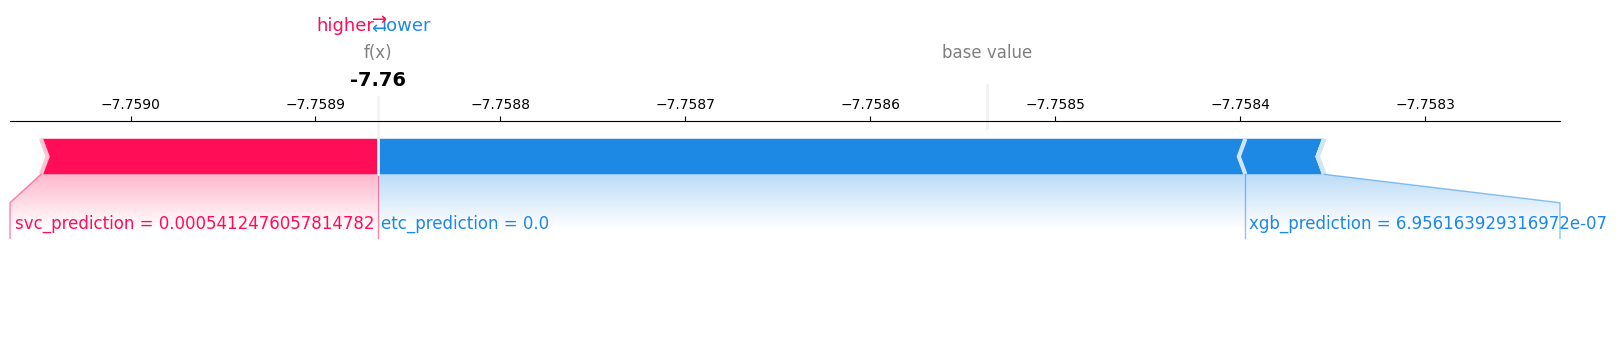

In [99]:
# Force Plot for a single prediction
idx = np.random.randint(len(X_test_meta_sampled))
shap.force_plot(explainer.expected_value, shap_values_sampled[idx].values, X_test_meta_sampled.iloc[idx], matplotlib=True)

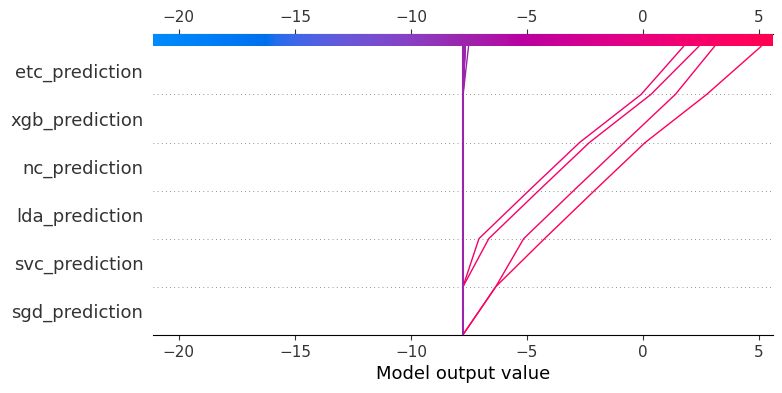

In [100]:
# Decision Plot
shap.decision_plot(explainer.expected_value, shap_values_sampled.values, X_test_meta_sampled)
plt.show()

### **Model Performance Summary**  

| **Model**                           | **Accuracy** | **Precision (Class 1)** | **Recall (Class 1)** | **F1-Score (Class 1)** | **AUC-PR**  |
|--------------------------------------|-------------|-------------------------|----------------------|-----------------------|------------|
| **Linear Discriminant Analysis (LDA)** | 0.9994      | 0.87                    | 0.74                 | 0.80                   | 0.8072     |
| **XGB Classifier**                   | **0.9996**  | 0.96                    | 0.78                 | **0.86**               | **0.8690** |
| **Nearest Centroid (NC)**            | 0.9994      | 0.87                    | 0.77                 | 0.82                   | 0.8189     |
| **SGD Classifier**                   | 0.9989      | 0.83                    | 0.46                 | 0.59                   | 0.6467     |
| **Extra Tree Classifier (ETC)**      | **0.9996**  | 0.96                    | 0.78                 | **0.86**               | **0.8690** |
| **Support Vector Classifier (SVC)**  | 0.9993      | **0.97**                | 0.61                 | 0.75                   | 0.8518     |
| **Stacking Ensemble**                | 0.9995      | **0.99**                | 0.73                 | 0.84                   | 0.8607     |
| **Voting Ensemble**                  | 0.9994      | 0.89                    | 0.74                 | 0.81                   | 0.8178     |

### **Observations**  
Out of all the models evaluated, XGBClassifier and Extra Tree Classifier received the highest accuracy scores of 99.96% and 0.8690 AUC-PR, which shows that they are the most advanced models when it comes to effectively detecting fraudulent transactions. Following right behind them, the Stacking Ensemble Model achieved 99.95% accuracy and 0.8607 AUC-PR, which highlights the strength of multi-model systems. With precision being their strength at 0.97 but recall relatively low at 0.61, SVC proved to be the most precise but did fail in identifying several fraudulent cases. With the lowest performance, SGD Classifier had a recall of 0.46 and AUC-PR of 0.6467, meaning it faced difficulties typecasting fraud cases. The voting Ensemble Model performed well with an accuracy of 99.94% and AUC-PR 0.8178; however, it was outperformed by the stacking model. In conclusion, XGBClassifier and Extra Tree Classifier are ideal choices as they provide the best options for high recall and AUC-PR, which are critical in fraud detection.